In [210]:
!pip install gensim

In [211]:
!pip install seaborn

In [212]:
import re
from sklearn.model_selection import train_test_split
import json
import pandas as pd
import urllib.parse
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import gensim
import tqdm

from sklearn import manifold as man
from sklearn import metrics as met
from sklearn import cluster as clu
from sklearn import pipeline as pip
from sklearn import preprocessing as pre
from sklearn import linear_model as lin
from sklearn import model_selection as mod

In [213]:
playlist_columns=['type','playlist_id','timestamp','metadata','subjects']


data=pd.read_csv("/Users/umutcancubukcu/PycharmProjects/CS455_HW1/Data/playlist.idomaar",sep="\t",names=playlist_columns)
data.head()

,type,playlist_id,timestamp,metadata,subjects
0,playlist,0,1216545588,"{""ID"":2973549,""Title"":""my_favorites"",""numtrack...","{""subjects"":[{""type"":""user"",""id"":41504}],""obje..."
1,playlist,1,1249326867,"{""ID"":5429703,""Title"":"""",""numtracks"":9,""durati...","{""subjects"":[{""type"":""user"",""id"":41504}],""obje..."
2,playlist,2,1257766688,"{""ID"":5926742,""Title"":""1989"",""numtracks"":16,""d...","{""subjects"":[{""type"":""user"",""id"":44542}],""obje..."
3,playlist,3,1248079275,"{""ID"":5353183,""Title"":""Fly me to the moon..."",...","{""subjects"":[{""type"":""user"",""id"":44542}],""obje..."
4,playlist,4,1175201268,"{""ID"":330569,""Title"":""The playlist who must no...","{""subjects"":[{""type"":""user"",""id"":44542}],""obje..."


In [214]:
track_sequences=[]
for subject in data['subjects']:
    id_list=[]
    parsed_dict=json.loads(subject)
    for obj in parsed_dict['objects']:
        try:
            id_list.append(obj['id'])
        except:
            pass
    track_sequences.append(id_list)


In [215]:
print(len(track_sequences))

57561


In [216]:
data_tracks=pd.read_csv("/Users/umutcancubukcu/PycharmProjects/CS455_HW1/Data/tracks.idomaar",sep="\t",names=['type', 'track_id', 'dummy_col', 'metadata', 'extra'])
data_tracks.head(10)

,type,track_id,dummy_col,metadata,extra
0,track,0,-1,"{""duration"":-1,""playcount"":4,""MBID"":null,""name...","{""artists"":[{""type"":""person"",""id"":0}],""albums""..."
1,track,1,-1,"{""duration"":-1,""playcount"":495,""MBID"":null,""na...","{""artists"":[{""type"":""person"",""id"":1}],""albums""..."
2,track,2,-1,"{""duration"":-1,""playcount"":2,""MBID"":null,""name...","{""artists"":[{""type"":""person"",""id"":2}],""albums""..."
3,track,3,-1,"{""duration"":-1,""playcount"":2,""MBID"":null,""name...","{""artists"":[{""type"":""person"",""id"":3}],""albums""..."
4,track,4,-1,"{""duration"":-1,""playcount"":1,""MBID"":null,""name...","{""artists"":[{""type"":""person"",""id"":4}],""albums""..."
5,track,5,-1,"{""duration"":-1,""playcount"":16,""MBID"":null,""nam...","{""artists"":[{""type"":""person"",""id"":5}],""albums""..."
6,track,6,-1,"{""duration"":-1,""playcount"":34,""MBID"":null,""nam...","{""artists"":[{""type"":""person"",""id"":6}],""albums""..."
7,track,7,-1,"{""duration"":-1,""playcount"":163,""MBID"":null,""na...","{""artists"":[{""type"":""person"",""id"":5}],""albums""..."
8,track,8,-1,"{""duration"":269000,""playcount"":163,""MBID"":""bba...","{""artists"":[{""type"":""person"",""id"":7}],""albums""..."
9,track,9,-1,"{""duration"":-1,""playcount"":12,""MBID"":null,""nam...","{""artists"":[{""type"":""person"",""id"":8}],""albums""..."


In [217]:
data_tracks.shape

(5675143, 5)

In [218]:
import re
import urllib.parse

def normalize_text(text):
    text = urllib.parse.unquote_plus(str(text))
    text = text.lower().strip()
    text = re.sub(r'\s+', ' ', text)
    text = re.sub(r'[^\w\s-]', '', text)
    text = text.replace(' ', '_')
    return text

In [219]:
track_dict={}

for row in data_tracks.itertuples():
    track_id=row.track_id
    artist_name=""
    song_name=""
    parsed_dict=json.loads(row.metadata)
    raw_name=parsed_dict['name']
    decoded_name=urllib.parse.unquote_plus(raw_name)
    if '/_/' in decoded_name:
        split_name = decoded_name.split('/_/', 1)
        artist_name = normalize_text(split_name[0])
        song_name = normalize_text(split_name[1])
        final_name = artist_name + '__' + song_name
        track_dict[track_id] = final_name



In [220]:
playlist_sentences = []

for sequence in track_sequences:
    row = []
    for track_id in sequence:
        if track_id in track_dict:
            row.append(track_dict[track_id])
    if len(row) > 0:
        playlist_sentences.append(row)

In [221]:
from sklearn.model_selection import train_test_split

train_sentences,test_sentences=train_test_split(
    playlist_sentences,
    train_size=0.8,
    test_size=0.2,
    random_state=42
)
print(len(train_sentences))
print(len(test_sentences))


38737
9685


 A2


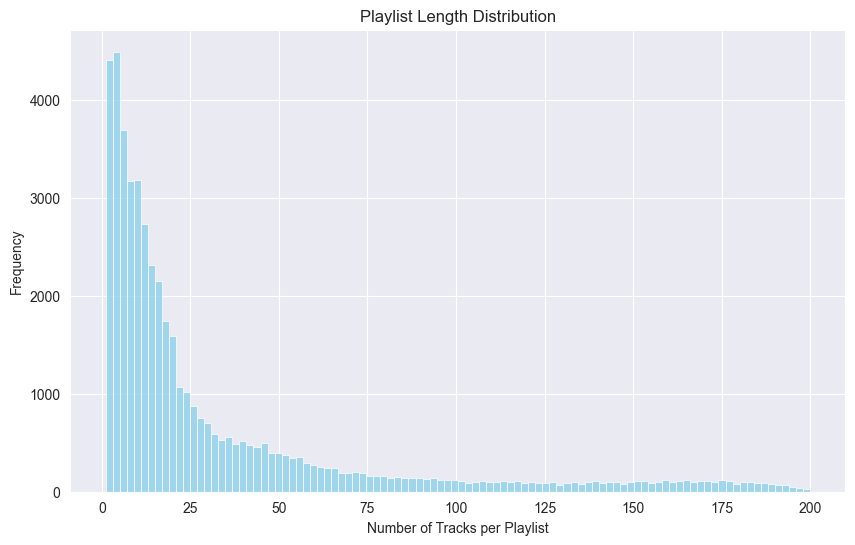

In [222]:
playlist_lengths=[len(p) for p in playlist_sentences]
#copy pasted from gemini

plt.figure(figsize=(10, 6))
sns.histplot(playlist_lengths, bins=100, kde=False, color='skyblue')
plt.title('Playlist Length Distribution')
plt.xlabel('Number of Tracks per Playlist')
plt.ylabel('Frequency')
plt.show()

In [223]:

all_tracks=[track for playlist in playlist_sentences for track in playlist]
track_counts=Counter(all_tracks)

total_tracks=len(track_counts)
print("Unique tracks:",total_tracks)

print("Top 20 Tracks:\n -------------")
for track,count in track_counts.most_common(20):
    print(f"{track.replace('_',' ')}: {count}")




Unique tracks: 440895
Top 20 Tracks:
 -------------
zz top  she loves my automobile: 31111
massive attack  teardrop: 495
joy division  love will tear us apart: 457
radiohead  karma police: 444
nirvana  smells like teen spirit: 421
mgmt  kids: 411
radiohead  creep: 408
oasis  wonderwall: 400
the rolling stones  paint it black: 388
the killers  mr brightside: 382
mgmt  time to pretend: 365
franz ferdinand  take me out: 354
muse  starlight: 339
depeche mode  enjoy the silence: 338
kings of leon  sex on fire: 332
coldplay  viva la vida: 327
led zeppelin  stairway to heaven: 327
radiohead  paranoid android: 325
system of a down  chop suey: 324
johnny cash  hurt: 319


In [224]:
all_artists=[track.split('__')[0] for track in all_tracks]
artist_counts=Counter(all_artists)

print("Top 20 Artists:\n----------")
for artist,count in artist_counts.most_common(20):
    print(f"{artist.replace('_',' ')}: {count}")

Top 20 Artists:
----------
zz top: 31788
radiohead: 7709
the beatles: 6544
coldplay: 4563
pink floyd: 4482
depeche mode: 4306
muse: 4302
metallica: 3988
the rolling stones: 3984
the cure: 3938
nirvana: 3736
nine inch nails: 3464
placebo: 3348
iron maiden: 3296
the killers: 3200
red hot chili peppers: 3139
david bowie: 3136
massive attack: 3034
u2: 3022
michael jackson: 2988


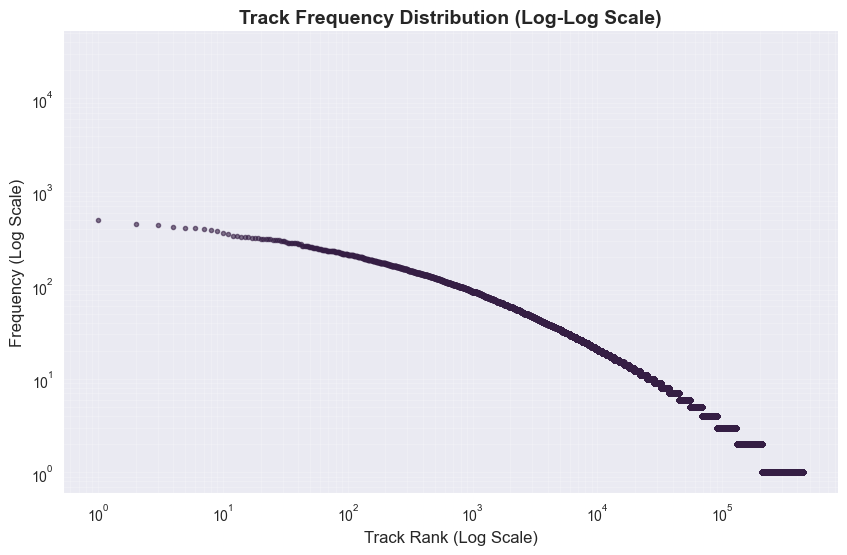

In [225]:
import matplotlib.pyplot as plt
import seaborn as sns


counts = sorted(track_counts.values(), reverse=True)

plt.figure(figsize=(10, 6))
plt.loglog(counts, marker='.', linestyle='none', alpha=0.6, color='#351e44')


plt.title('Track Frequency Distribution (Log-Log Scale)', fontsize=14, fontweight='bold')
plt.xlabel('Track Rank (Log Scale)', fontsize=12)
plt.ylabel('Frequency (Log Scale)', fontsize=12)

plt.grid(True, which="both", ls="-", alpha=0.2)


sns.despine()

plt.show()

In [226]:
hapax_count=sum(1 for count in track_counts.values() if count == 1)
print("hapax count: ", hapax_count)

hapax count:  232317


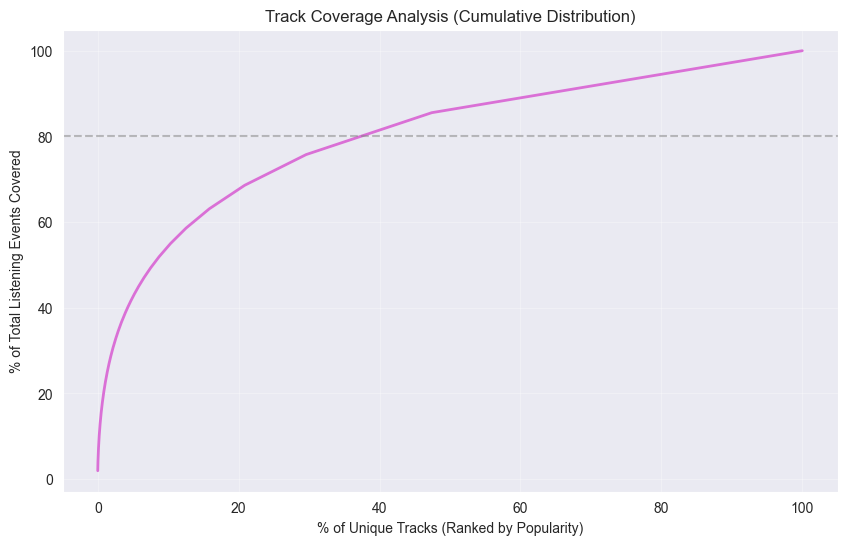

Top 1% of tracks cover: 21.84% of events
Top 5% of tracks cover: 42.60% of events
Top 20% of tracks cover: 67.68% of events


In [227]:
import numpy as np
import matplotlib.pyplot as plt

counts = sorted(track_counts.values(), reverse=True)
total_interactions=sum(counts)

cumulative_counts=np.cumsum(counts)
coverage_percentage=(cumulative_counts/total_interactions)*100

unique_tracks_pct=np.linspace(0,100,len(counts))

plt.figure(figsize=(10, 6))
plt.plot(unique_tracks_pct, coverage_percentage, color='orchid', linewidth=2)

# Add a reference point (e.g., where is the 80% coverage?)
plt.axhline(y=80, color='grey', linestyle='--', alpha=0.5)
plt.title('Track Coverage Analysis (Cumulative Distribution)')
plt.xlabel('% of Unique Tracks (Ranked by Popularity)')
plt.ylabel('% of Total Listening Events Covered')
plt.grid(True, alpha=0.3)
plt.show()

# 5. Precise Statistics
top_1_pct_limit = int(len(counts) * 0.01)
top_5_pct_limit = int(len(counts) * 0.05)
top_20_pct_limit = int(len(counts) * 0.20)

print(f"Top 1% of tracks cover: {coverage_percentage[top_1_pct_limit]:.2f}% of events")
print(f"Top 5% of tracks cover: {coverage_percentage[top_5_pct_limit]:.2f}% of events")
print(f"Top 20% of tracks cover: {coverage_percentage[top_20_pct_limit]:.2f}% of events")

B1

In [228]:
import time
from gensim.models.callbacks import CallbackAny2Vec

class EpochLogger(CallbackAny2Vec):
    def __init__(self):
        self.epoch = 0
        self.start_time = time.time()

    def on_epoch_begin(self, model):
        self.epoch_start = time.time()
        print(f"Epoch {self.epoch + 1} started")

    def on_epoch_end(self, model):
        epoch_time = time.time() - self.epoch_start
        total_time = time.time() - self.start_time
        print(f"Epoch {self.epoch + 1} finished | epoch_time={epoch_time:.2f}s | total_time={total_time:.2f}s")
        self.epoch += 1

In [229]:
from gensim.models import Word2Vec

epoch_logger = EpochLogger()

model_baseline = Word2Vec(
    sentences=train_sentences,
    vector_size=100,
    window=5,
    min_count=5,
    sg=1,
    negative=5,
    ns_exponent=0.75,
    workers=4,
    epochs=5,
    seed=42,
    callbacks=[epoch_logger]
)

Epoch 1 started
Epoch 1 finished | epoch_time=0.78s | total_time=1.23s
Epoch 2 started


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Epoch 2 finished | epoch_time=0.77s | total_time=2.00s
Epoch 3 started


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Epoch 3 finished | epoch_time=0.78s | total_time=2.78s
Epoch 4 started
Epoch 4 finished | epoch_time=0.77s | total_time=3.55s
Epoch 5 started


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Epoch 5 finished | epoch_time=0.78s | total_time=4.34s


b2


In [230]:
baseline_params = {
    "vector_size": 100,
    "window": 5,
    "min_count": 5,
    "sg": 1,
    "negative": 5,
    "ns_exponent": 0.75,
    "workers": 4,
    "epochs": 5,
    "seed": 42
}

experiments = {
    "sg": [0, 1],
    "window": [5, 20, 40],
    "negative": [5, 10, 15],
    "ns_exponent": [-1.0, -0.5, 0, 0.5, 1.0],
    "min_count": [3, 5, 10],
    "vector_size": [50, 100, 300],
    "epochs": [5, 20, 50]
}

C1

In [231]:
import numpy as np
import math

def calculate_metrics(model, test_playlists, approach, k_values=[5, 10, 20, 50]):
    hits = {k: 0 for k in k_values}
    ndcg_scores = {k: 0.0 for k in k_values}
    total_valid_playlists = 0

    max_k = max(k_values)

    for playlist in test_playlists:
        if len(playlist) < 2:
            continue

        context_songs = playlist[:-1]
        target_song = playlist[-1]

        # Target must be in vocabulary, otherwise cannot be predicted
        if target_song not in model.wv:
            continue

        query_vector = None
        songs_to_exclude = set()

        if approach == "average":
            # Approach 1: use average of all context-song embeddings
            vectors = [model.wv[s] for s in context_songs if s in model.wv]
            if not vectors:
                continue

            query_vector = np.mean(vectors, axis=0)
            songs_to_exclude = set(context_songs)

        elif approach == "single":
            # Approach 2: use second-to-last song as query
            last_song = context_songs[-1]
            if last_song not in model.wv:
                continue

            query_vector = model.wv[last_song]
            songs_to_exclude = set(context_songs)

        else:
            raise ValueError("approach must be either 'average' or 'single'")

        # Ask for more candidates because we will filter some out
        raw_recommendations = model.wv.most_similar(positive=[query_vector], topn=max_k + len(songs_to_exclude) + 20)

        recommended_songs = []
        for song, score in raw_recommendations:
            if song not in songs_to_exclude:
                recommended_songs.append(song)
            if len(recommended_songs) == max_k:
                break

        total_valid_playlists += 1

        if target_song in recommended_songs:
            rank = recommended_songs.index(target_song) + 1  # 1-based rank

            for k in k_values:
                if rank <= k:
                    hits[k] += 1
                    ndcg_scores[k] += 1.0 / math.log2(rank + 1)

    results = {}
    if total_valid_playlists == 0:
        for k in k_values:
            results[f"HR@{k}"] = 0.0
            results[f"NDCG@{k}"] = 0.0
        return results

    for k in k_values:
        results[f"HR@{k}"] = hits[k] / total_valid_playlists
        results[f"NDCG@{k}"] = ndcg_scores[k] / total_valid_playlists

    return results

In [232]:
avg_results = calculate_metrics(model_baseline, test_sentences, approach="average")
single_results = calculate_metrics(model_baseline, test_sentences, approach="single")
print(avg_results)
print(single_results)

{'HR@5': 0.010285714285714285, 'NDCG@5': 0.006691551666345585, 'HR@10': 0.01622857142857143, 'NDCG@10': 0.008584679524382216, 'HR@20': 0.024685714285714287, 'NDCG@20': 0.010698306471374897, 'HR@50': 0.03725714285714286, 'NDCG@50': 0.013171851405716358}
{'HR@5': 0.021882598124348732, 'NDCG@5': 0.015440296707335625, 'HR@10': 0.03265022577283779, 'NDCG@10': 0.0189461334354857, 'HR@20': 0.045154567558179926, 'NDCG@20': 0.022068412782876707, 'HR@50': 0.06668982285515804, 'NDCG@50': 0.02634658657999091}


In [233]:
import pandas as pd
from gensim.models import Word2Vec
from gensim.models.callbacks import CallbackAny2Vec
import gc
import time

class EpochLogger(CallbackAny2Vec):
    def __init__(self, label="model"):
        self.label = label
        self.epoch = 0
        self.train_start_time = None
        self.epoch_start_time = None

    def on_train_begin(self, model):
        self.train_start_time = time.time()
        print(f"[{self.label}] Training started")

    def on_epoch_begin(self, model):
        self.epoch_start_time = time.time()
        print(f"[{self.label}] Epoch {self.epoch + 1} started")

    def on_epoch_end(self, model):
        epoch_time = time.time() - self.epoch_start_time
        total_time = time.time() - self.train_start_time
        print(
            f"[{self.label}] Epoch {self.epoch + 1} finished | "
            f"epoch_time={epoch_time:.2f}s | total_time={total_time:.2f}s"
        )
        self.epoch += 1

    def on_train_end(self, model):
        total_time = time.time() - self.train_start_time
        print(f"[{self.label}] Training finished | total_time={total_time:.2f}s")


# 1. Setup Parameters and Results Storage
k_values = [5, 10, 20, 50]
approaches = ["single", "average"]
results_master_list = []
training_logs = []

# 2. Establish Baseline Benchmarks (B.1)
print("--- Establishing Baseline for all Approaches and K-values ---")

baseline_logger = EpochLogger(label="baseline")
baseline_wall_start = time.time()

baseline_model = Word2Vec(
    sentences=train_sentences,
    **baseline_params,
    callbacks=[baseline_logger]
)

baseline_wall_end = time.time()
baseline_wall_time = baseline_wall_end - baseline_wall_start

training_logs.append({
    "Model_Label": "baseline",
    "Parameter": "baseline",
    "Value": "baseline",
    "Wall_Time_Seconds": baseline_wall_time,
    "Epochs": baseline_params["epochs"]
})

print(f"[baseline] Total wall-clock time: {baseline_wall_time:.2f}s")

baseline_cache = {}
for app in approaches:
    metrics = calculate_metrics(baseline_model, test_sentences, approach=app, k_values=k_values)
    baseline_cache[app] = metrics

# Clear baseline model to save RAM
del baseline_model
gc.collect()

# 3. Sensitivity Analysis Loop (B.2)
for param_name, values in experiments.items():
    print(f"\nTesting Category: {param_name}")

    for value in values:
        if value == baseline_params[param_name]:
            print(f"  > Skipping {value} (Baseline). Using cached results.")
            for app in approaches:
                entry = {'Parameter': param_name, 'Value': value, 'Approach': app}
                entry.update(baseline_cache[app])
                results_master_list.append(entry)
            continue

        current_params = baseline_params.copy()
        current_params[param_name] = value
        run_label = f"{param_name}={value}"

        print(f"  > Training: {run_label}")

        exp_logger = EpochLogger(label=run_label)
        train_wall_start = time.time()

        model = Word2Vec(
            sentences=train_sentences,
            **current_params,
            callbacks=[exp_logger]
        )

        train_wall_end = time.time()
        train_wall_time = train_wall_end - train_wall_start

        training_logs.append({
            "Model_Label": run_label,
            "Parameter": param_name,
            "Value": value,
            "Wall_Time_Seconds": train_wall_time,
            "Epochs": current_params["epochs"]
        })

        print(f"[{run_label}] Total wall-clock time: {train_wall_time:.2f}s")

        for app in approaches:
            metrics = calculate_metrics(model, test_sentences, approach=app, k_values=k_values)
            entry = {'Parameter': param_name, 'Value': value, 'Approach': app}
            entry.update(metrics)
            results_master_list.append(entry)

        del model
        gc.collect()

# 4. Create master results DataFrame
master_df = pd.DataFrame(results_master_list)

# 5. Create training logs DataFrame
training_logs_df = pd.DataFrame(training_logs)
print("\n--- Training Logs ---")
print(training_logs_df)

# 6. Split into 8 DataFrames
dfs = {}
for app in approaches:
    for k in k_values:
        name = f"df_{app}_k{k}"
        cols = ['Parameter', 'Value', f'HR@{k}', f'NDCG@{k}']
        dfs[name] = master_df[master_df['Approach'] == app][cols].copy()
        globals()[name] = dfs[name]

print("\n--- DataFrames Created ---")
print(f"Available: {', '.join(dfs.keys())}")

--- Establishing Baseline for all Approaches and K-values ---
[baseline] Training started
[baseline] Epoch 1 started
[baseline] Epoch 1 finished | epoch_time=0.77s | total_time=0.77s
[baseline] Epoch 2 started
[baseline] Epoch 2 finished | epoch_time=0.78s | total_time=1.55s
[baseline] Epoch 3 started


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


[baseline] Epoch 3 finished | epoch_time=0.77s | total_time=2.32s
[baseline] Epoch 4 started
[baseline] Epoch 4 finished | epoch_time=0.77s | total_time=3.09s
[baseline] Epoch 5 started
[baseline] Epoch 5 finished | epoch_time=0.77s | total_time=3.86s
[baseline] Training finished | total_time=3.86s
[baseline] Total wall-clock time: 4.28s

Testing Category: sg
  > Training: sg=0
[sg=0] Training started
[sg=0] Epoch 1 started
[sg=0] Epoch 1 finished | epoch_time=0.24s | total_time=0.24s
[sg=0] Epoch 2 started
[sg=0] Epoch 2 finished | epoch_time=0.23s | total_time=0.47s
[sg=0] Epoch 3 started
[sg=0] Epoch 3 finished | epoch_time=0.23s | total_time=0.70s
[sg=0] Epoch 4 started
[sg=0] Epoch 4 finished | epoch_time=0.23s | total_time=0.93s
[sg=0] Epoch 5 started
[sg=0] Epoch 5 finished | epoch_time=0.24s | total_time=1.17s
[sg=0] Training finished | total_time=1.17s
[sg=0] Total wall-clock time: 1.59s
  > Skipping 1 (Baseline). Using cached results.

Testing Category: window
  > Skipping 5 

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


[window=20] Epoch 2 finished | epoch_time=2.01s | total_time=4.01s
[window=20] Epoch 3 started


...

[epochs=50] Epoch 46 finished | epoch_time=0.81s | total_time=36.94s
[epochs=50] Epoch 47 started


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


[epochs=50] Epoch 47 finished | epoch_time=0.82s | total_time=37.76s
[epochs=50] Epoch 48 started
[epochs=50] Epoch 48 finished | epoch_time=0.83s | total_time=38.59s
[epochs=50] Epoch 49 started
[epochs=50] Epoch 49 finished | epoch_time=0.82s | total_time=39.41s
[epochs=50] Epoch 50 started


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


[epochs=50] Epoch 50 finished | epoch_time=0.80s | total_time=40.21s
[epochs=50] Training finished | total_time=40.21s
[epochs=50] Total wall-clock time: 40.65s

--- Training Logs ---
         Model_Label    Parameter     Value  Wall_Time_Seconds  Epochs
0           baseline     baseline  baseline           4.275516       5
1               sg=0           sg         0           1.586723       5
2          window=20       window        20          10.925590       5
3          window=40       window        40          17.570591       5
4        negative=10     negative        10           7.097573       5
5        negative=15     negative        15           9.909953       5
6   ns_exponent=-1.0  ns_exponent      -1.0           4.478713       5
7   ns_exponent=-0.5  ns_exponent      -0.5           4.508766       5
8      ns_exponent=0  ns_exponent         0           4.529950       5
9    ns_exponent=0.5  ns_exponent       0.5           4.433130       5
10   ns_exponent=1.0  ns_exponent  

In [234]:
print(df_single_k5)

      Parameter  Value      HR@5    NDCG@5
0            sg    0.0  0.007294  0.004841
2            sg    1.0  0.024661  0.017974
4        window    5.0  0.024661  0.017974
6        window   20.0  0.036471  0.024718
8        window   40.0  0.040986  0.028076
10     negative    5.0  0.024661  0.017974
12     negative   10.0  0.027787  0.019315
14     negative   15.0  0.034387  0.022405
16  ns_exponent   -1.0  0.004863  0.002938
18  ns_exponent   -0.5  0.013199  0.009526
20  ns_exponent    0.0  0.023272  0.016165
22  ns_exponent    0.5  0.022577  0.016362
24  ns_exponent    1.0  0.028135  0.019554
26    min_count    3.0  0.015780  0.011114
28    min_count    5.0  0.024661  0.017974
30    min_count   10.0  0.043089  0.029377
32  vector_size   50.0  0.025356  0.017506
34  vector_size  100.0  0.024661  0.017974
36  vector_size  300.0  0.020493  0.015051
38       epochs    5.0  0.024661  0.017974
40       epochs   20.0  0.044807  0.031468
42       epochs   50.0  0.043765  0.031840


In [235]:
print(df_single_k10)

      Parameter  Value     HR@10   NDCG@10
0            sg    0.0  0.009031  0.005376
2            sg    1.0  0.035082  0.021305
4        window    5.0  0.035082  0.021305
6        window   20.0  0.053838  0.030377
8        window   40.0  0.058701  0.033780
10     negative    5.0  0.035082  0.021305
12     negative   10.0  0.043765  0.024472
14     negative   15.0  0.047239  0.026501
16  ns_exponent   -1.0  0.009726  0.004539
18  ns_exponent   -0.5  0.023967  0.012983
20  ns_exponent    0.0  0.032650  0.019151
22  ns_exponent    0.5  0.032998  0.019688
24  ns_exponent    1.0  0.043071  0.024404
26    min_count    3.0  0.021889  0.013038
28    min_count    5.0  0.035082  0.021305
30    min_count   10.0  0.065473  0.036579
32  vector_size   50.0  0.035776  0.020937
34  vector_size  100.0  0.035082  0.021305
36  vector_size  300.0  0.027440  0.017235
38       epochs    5.0  0.035082  0.021305
40       epochs   20.0  0.064258  0.037769
42       epochs   50.0  0.058354  0.036641


In [236]:
print(df_single_k20)

      Parameter  Value     HR@20   NDCG@20
0            sg    0.0  0.013546  0.006467
2            sg    1.0  0.046197  0.024149
4        window    5.0  0.046197  0.024149
6        window   20.0  0.072247  0.035001
8        window   40.0  0.085794  0.040681
10     negative    5.0  0.046197  0.024149
12     negative   10.0  0.057312  0.027864
14     negative   15.0  0.062869  0.030440
16  ns_exponent   -1.0  0.013546  0.005483
18  ns_exponent   -0.5  0.029871  0.014465
20  ns_exponent    0.0  0.043071  0.021693
22  ns_exponent    0.5  0.043071  0.022247
24  ns_exponent    1.0  0.058354  0.028289
26    min_count    3.0  0.030033  0.015088
28    min_count    5.0  0.046197  0.024149
30    min_count   10.0  0.092334  0.043313
32  vector_size   50.0  0.049323  0.024390
34  vector_size  100.0  0.046197  0.024149
36  vector_size  300.0  0.039250  0.020215
38       epochs    5.0  0.046197  0.024149
40       epochs   20.0  0.086836  0.043482
42       epochs   50.0  0.076415  0.041209


In [237]:
print(df_single_k50)

      Parameter  Value     HR@50   NDCG@50
0            sg    0.0  0.020493  0.007823
2            sg    1.0  0.067385  0.028340
4        window    5.0  0.067385  0.028340
6        window   20.0  0.105940  0.041713
8        window   40.0  0.122265  0.047884
10     negative    5.0  0.067385  0.028340
12     negative   10.0  0.086141  0.033472
14     negative   15.0  0.087530  0.035322
16  ns_exponent   -1.0  0.019451  0.006650
18  ns_exponent   -0.5  0.036471  0.015774
20  ns_exponent    0.0  0.055575  0.024235
22  ns_exponent    0.5  0.066690  0.026929
24  ns_exponent    1.0  0.080931  0.032748
26    min_count    3.0  0.043013  0.017686
28    min_count    5.0  0.067385  0.028340
30    min_count   10.0  0.134303  0.051590
32  vector_size   50.0  0.070511  0.028585
34  vector_size  100.0  0.067385  0.028340
36  vector_size  300.0  0.056270  0.023554
38       epochs    5.0  0.067385  0.028340
40       epochs   20.0  0.125391  0.051111
42       epochs   50.0  0.111497  0.048089


In [238]:
print(df_average_k5)

      Parameter  Value      HR@5    NDCG@5
1            sg    0.0  0.004343  0.003168
3            sg    1.0  0.009829  0.006826
5        window    5.0  0.009829  0.006826
7        window   20.0  0.017829  0.012219
9        window   40.0  0.020114  0.013686
11     negative    5.0  0.009829  0.006826
13     negative   10.0  0.010743  0.007179
15     negative   15.0  0.012114  0.007861
17  ns_exponent   -1.0  0.004114  0.002616
19  ns_exponent   -0.5  0.006629  0.004274
21  ns_exponent    0.0  0.009829  0.006599
23  ns_exponent    0.5  0.009829  0.006097
25  ns_exponent    1.0  0.010743  0.006775
27    min_count    3.0  0.006873  0.004696
29    min_count    5.0  0.009829  0.006826
31    min_count   10.0  0.016289  0.010336
33  vector_size   50.0  0.011200  0.007553
35  vector_size  100.0  0.009829  0.006826
37  vector_size  300.0  0.008229  0.005406
39       epochs    5.0  0.009829  0.006826
41       epochs   20.0  0.022400  0.015791
43       epochs   50.0  0.020800  0.013970


In [239]:
print(df_average_k10)

      Parameter  Value     HR@10   NDCG@10
1            sg    0.0  0.007543  0.004225
3            sg    1.0  0.016457  0.008969
5        window    5.0  0.016457  0.008969
7        window   20.0  0.026971  0.015201
9        window   40.0  0.032457  0.017681
11     negative    5.0  0.016457  0.008969
13     negative   10.0  0.016000  0.008898
15     negative   15.0  0.019200  0.010144
17  ns_exponent   -1.0  0.006400  0.003367
19  ns_exponent   -0.5  0.008457  0.004852
21  ns_exponent    0.0  0.014629  0.008148
23  ns_exponent    0.5  0.014629  0.007625
25  ns_exponent    1.0  0.017829  0.009075
27    min_count    3.0  0.010775  0.005949
29    min_count    5.0  0.016457  0.008969
31    min_count   10.0  0.027467  0.013925
33  vector_size   50.0  0.017143  0.009422
35  vector_size  100.0  0.016457  0.008969
37  vector_size  300.0  0.013029  0.006940
39       epochs    5.0  0.016457  0.008969
41       epochs   20.0  0.033371  0.019254
43       epochs   50.0  0.029943  0.016813


In [240]:
print(df_average_k20)

      Parameter  Value     HR@20   NDCG@20
1            sg    0.0  0.010743  0.005033
3            sg    1.0  0.024686  0.011050
5        window    5.0  0.024686  0.011050
7        window   20.0  0.040457  0.018593
9        window   40.0  0.048686  0.021725
11     negative    5.0  0.024686  0.011050
13     negative   10.0  0.026514  0.011535
15     negative   15.0  0.027657  0.012293
17  ns_exponent   -1.0  0.008457  0.003895
19  ns_exponent   -0.5  0.014171  0.006286
21  ns_exponent    0.0  0.023314  0.010333
23  ns_exponent    0.5  0.021257  0.009283
25  ns_exponent    1.0  0.026743  0.011348
27    min_count    3.0  0.015976  0.007243
29    min_count    5.0  0.024686  0.011050
31    min_count   10.0  0.040243  0.017152
33  vector_size   50.0  0.026057  0.011647
35  vector_size  100.0  0.024686  0.011050
37  vector_size  300.0  0.021029  0.008960
39       epochs    5.0  0.024686  0.011050
41       epochs   20.0  0.046629  0.022580
43       epochs   50.0  0.042743  0.020025


In [241]:
print(df_average_k50)

      Parameter  Value     HR@50   NDCG@50
1            sg    0.0  0.015771  0.006032
3            sg    1.0  0.035886  0.013259
5        window    5.0  0.035886  0.013259
7        window   20.0  0.062857  0.023028
9        window   40.0  0.072686  0.026466
11     negative    5.0  0.035886  0.013259
13     negative   10.0  0.044571  0.015097
15     negative   15.0  0.048000  0.016346
17  ns_exponent   -1.0  0.011429  0.004474
19  ns_exponent   -0.5  0.021257  0.007706
21  ns_exponent    0.0  0.034514  0.012534
23  ns_exponent    0.5  0.033371  0.011670
25  ns_exponent    1.0  0.042971  0.014604
27    min_count    3.0  0.023964  0.008814
29    min_count    5.0  0.035886  0.013259
31    min_count   10.0  0.063877  0.021887
33  vector_size   50.0  0.035657  0.013592
35  vector_size  100.0  0.035886  0.013259
37  vector_size  300.0  0.030857  0.010870
39       epochs    5.0  0.035886  0.013259
41       epochs   20.0  0.078171  0.028826
43       epochs   50.0  0.067657  0.024961


In [242]:
candidate_configs = {}

# Parameters that should be integers in Word2Vec
int_params = ['vector_size', 'window', 'negative', 'min_count', 'epochs', 'sg']

for df_name, df in dfs.items():
    print(f"Building candidate config for {df_name}...")

    k_val = int(df_name.split('_k')[-1])
    approach_type = 'single' if 'single' in df_name else 'average'

    candidate_params = baseline_params.copy()

    for param in experiments.keys():
        param_rows = df[df['Parameter'] == param]

        if not param_rows.empty:
            # pick the best VALUE for this parameter from the one-factor experiment
            best_row = param_rows.loc[param_rows[f'HR@{k_val}'].idxmax()]
            raw_value = best_row['Value']

            if param in int_params:
                candidate_params[param] = int(raw_value)
            else:
                candidate_params[param] = float(raw_value)

    candidate_configs[df_name] = {
        'params': candidate_params,
        'approach': approach_type,
        'k': k_val,
        'source': 'combined_from_one_factor_best_values'
    }

print("Candidate configurations built.")
print(candidate_configs['df_single_k10'])

Building candidate config for df_single_k5...
Building candidate config for df_single_k10...
Building candidate config for df_single_k20...
Building candidate config for df_single_k50...
Building candidate config for df_average_k5...
Building candidate config for df_average_k10...
Building candidate config for df_average_k20...
Building candidate config for df_average_k50...
Candidate configurations built.
{'params': {'vector_size': 50, 'window': 40, 'min_count': 10, 'sg': 1, 'negative': 15, 'ns_exponent': 1.0, 'workers': 4, 'epochs': 20, 'seed': 42}, 'approach': 'single', 'k': 10, 'source': 'combined_from_one_factor_best_values'}


In [243]:
import pandas as pd
from gensim.models import Word2Vec
import time
import gc

final_candidate_results = []
final_candidate_training_logs = []

for name, config in candidate_configs.items():
    print(f"\n--- Training Candidate Model for: {name} ---")
    print(f"Using Params: {config['params']}")

    candidate_logger = EpochLogger(label=f"candidate::{name}")
    train_wall_start = time.time()

    model = Word2Vec(
        sentences=train_sentences,
        **config['params'],
        callbacks=[candidate_logger]
    )

    train_wall_end = time.time()
    train_wall_time = train_wall_end - train_wall_start

    print(f"[candidate::{name}] Total wall-clock time: {train_wall_time:.2f}s")

    metrics = calculate_metrics(
        model,
        test_sentences,
        approach=config['approach'],
        k_values=[5, 10, 20, 50]
    )

    result_row = {
        'Candidate_Name': f"{config['approach']}_selected_by_k{config['k']}",
        'Source_df': name,
        'Approach': config['approach'],
        'Selection_K': config['k']
    }

    for k in [5, 10, 20, 50]:
        result_row[f'HR@{k}'] = metrics[f'HR@{k}']
        result_row[f'NDCG@{k}'] = metrics[f'NDCG@{k}']

    final_candidate_results.append(result_row)

    final_candidate_training_logs.append({
        'Candidate_Name': f"{config['approach']}_selected_by_k{config['k']}",
        'Source_df': name,
        'Approach': config['approach'],
        'Selection_K': config['k'],
        'Wall_Time_Seconds': train_wall_time,
        'Epochs': config['params']['epochs']
    })

    del model
    gc.collect()

final_candidate_df = pd.DataFrame(final_candidate_results)
final_candidate_df = final_candidate_df.sort_values(by=['Approach', 'HR@10'], ascending=[True, False])

final_candidate_logs_df = pd.DataFrame(final_candidate_training_logs)
final_candidate_logs_df = final_candidate_logs_df.sort_values(by=['Approach', 'Wall_Time_Seconds'], ascending=[True, True])

print("\n--- Final Candidate Results ---")
print(final_candidate_df)

print("\n--- Final Candidate Training Logs ---")
print(final_candidate_logs_df)


--- Training Candidate Model for: df_single_k5 ---
Using Params: {'vector_size': 50, 'window': 40, 'min_count': 10, 'sg': 1, 'negative': 15, 'ns_exponent': 1.0, 'workers': 4, 'epochs': 20, 'seed': 42}
[candidate::df_single_k5] Training started
[candidate::df_single_k5] Epoch 1 started
[candidate::df_single_k5] Epoch 1 finished | epoch_time=4.05s | total_time=4.05s
[candidate::df_single_k5] Epoch 2 started
[candidate::df_single_k5] Epoch 2 finished | epoch_time=4.25s | total_time=8.30s
[candidate::df_single_k5] Epoch 3 started
[candidate::df_single_k5] Epoch 3 finished | epoch_time=4.26s | total_time=12.55s
[candidate::df_single_k5] Epoch 4 started


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


[candidate::df_single_k5] Epoch 4 finished | epoch_time=4.26s | total_time=16.82s
[candidate::df_single_k5] Epoch 5 started
[candidate::df_single_k5] Epoch 5 finished | epoch_time=4.27s | total_time=21.09s
[candidate::df_single_k5] Epoch 6 started
[candidate::df_single_k5] Epoch 6 finished | epoch_time=4.27s | total_time=25.35s
[candidate::df_single_k5] Epoch 7 started
[candidate::df_single_k5] Epoch 7 finished | epoch_time=4.28s | total_time=29.63s
[candidate::df_single_k5] Epoch 8 started
[candidate::df_single_k5] Epoch 8 finished | epoch_time=4.28s | total_time=33.91s
[candidate::df_single_k5] Epoch 9 started
[candidate::df_single_k5] Epoch 9 finished | epoch_time=4.26s | total_time=38.17s
[candidate::df_single_k5] Epoch 10 started


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


[candidate::df_single_k5] Epoch 10 finished | epoch_time=4.32s | total_time=42.49s
[candidate::df_single_k5] Epoch 11 started


...

[candidate::df_average_k50] Epoch 14 finished | epoch_time=4.95s | total_time=72.32s
[candidate::df_average_k50] Epoch 15 started


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


[candidate::df_average_k50] Epoch 15 finished | epoch_time=4.96s | total_time=77.28s
[candidate::df_average_k50] Epoch 16 started
[candidate::df_average_k50] Epoch 16 finished | epoch_time=4.98s | total_time=82.26s
[candidate::df_average_k50] Epoch 17 started
[candidate::df_average_k50] Epoch 17 finished | epoch_time=4.87s | total_time=87.13s
[candidate::df_average_k50] Epoch 18 started


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


[candidate::df_average_k50] Epoch 18 finished | epoch_time=4.87s | total_time=92.00s
[candidate::df_average_k50] Epoch 19 started
[candidate::df_average_k50] Epoch 19 finished | epoch_time=4.89s | total_time=96.89s
[candidate::df_average_k50] Epoch 20 started
[candidate::df_average_k50] Epoch 20 finished | epoch_time=4.88s | total_time=101.77s
[candidate::df_average_k50] Training finished | total_time=101.77s
[candidate::df_average_k50] Total wall-clock time: 102.06s

--- Final Candidate Results ---
            Candidate_Name       Source_df Approach  Selection_K      HR@5  \
6  average_selected_by_k20  df_average_k20  average           20  0.060364   
7  average_selected_by_k50  df_average_k50  average           50  0.063877   
5  average_selected_by_k10  df_average_k10  average           10  0.059725   
4   average_selected_by_k5   df_average_k5  average            5  0.060045   
1   single_selected_by_k10   df_single_k10   single           10  0.092893   
3   single_selected_by_k50 

In [244]:
import time
from gensim.models import Word2Vec

# Select best validated candidates based on HR@10
best_single_row = final_candidate_df[final_candidate_df['Approach'] == 'single'] \
    .sort_values(by='HR@10', ascending=False).iloc[0]

best_average_row = final_candidate_df[final_candidate_df['Approach'] == 'average'] \
    .sort_values(by='HR@10', ascending=False).iloc[0]

params_single = candidate_configs[best_single_row['Source_df']]['params']
params_average = candidate_configs[best_average_row['Source_df']]['params']

print("Best validated single-query config:")
print(best_single_row)

print("\nBest validated average-context config:")
print(best_average_row)

# Train final single-query model with logs
print("\n--- Training Final Single Query Model (Paper Approach) ---")
single_logger = EpochLogger(label="final_single")
single_start = time.time()

model_single = Word2Vec(
    sentences=train_sentences,
    **params_single,
    callbacks=[single_logger]
)

single_end = time.time()
single_wall_time = single_end - single_start
print(f"[final_single] Total wall-clock time: {single_wall_time:.2f}s")

# Train final average-context model with logs
print("\n--- Training Final Context Averaging Model (Our Approach) ---")
avg_logger = EpochLogger(label="final_average")
avg_start = time.time()

model_avg = Word2Vec(
    sentences=train_sentences,
    **params_average,
    callbacks=[avg_logger]
)

avg_end = time.time()
avg_wall_time = avg_end - avg_start
print(f"[final_average] Total wall-clock time: {avg_wall_time:.2f}s")

# Optional: store final model training logs in a dataframe
final_model_logs_df = pd.DataFrame([
    {
        "Model": "final_single",
        "Source_df": best_single_row["Source_df"],
        "Selection_K": best_single_row["Selection_K"],
        "HR@10": best_single_row["HR@10"],
        "NDCG@10": best_single_row["NDCG@10"],
        "Wall_Time_Seconds": single_wall_time,
        "Epochs": params_single["epochs"]
    },
    {
        "Model": "final_average",
        "Source_df": best_average_row["Source_df"],
        "Selection_K": best_average_row["Selection_K"],
        "HR@10": best_average_row["HR@10"],
        "NDCG@10": best_average_row["NDCG@10"],
        "Wall_Time_Seconds": avg_wall_time,
        "Epochs": params_average["epochs"]
    }
])

print("\n--- Final Model Training Logs ---")
print(final_model_logs_df)

Best validated single-query config:
Candidate_Name    single_selected_by_k10
Source_df                  df_single_k10
Approach                          single
Selection_K                           10
HR@5                            0.092893
NDCG@5                          0.065392
HR@10                           0.133744
NDCG@10                         0.078375
HR@20                           0.171796
NDCG@20                         0.087938
HR@50                           0.219922
NDCG@50                         0.097611
Name: 1, dtype: object

Best validated average-context config:
Candidate_Name    average_selected_by_k20
Source_df                  df_average_k20
Approach                          average
Selection_K                            20
HR@5                             0.060364
NDCG@5                           0.042358
HR@10                            0.091345
NDCG@10                          0.052329
HR@20                            0.120089
NDCG@20                        

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


[final_single] Epoch 1 finished | epoch_time=4.10s | total_time=4.10s
[final_single] Epoch 2 started
[final_single] Epoch 2 finished | epoch_time=4.25s | total_time=8.35s
[final_single] Epoch 3 started
[final_single] Epoch 3 finished | epoch_time=4.27s | total_time=12.61s
[final_single] Epoch 4 started
[final_single] Epoch 4 finished | epoch_time=4.26s | total_time=16.87s
[final_single] Epoch 5 started


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


[final_single] Epoch 5 finished | epoch_time=4.33s | total_time=21.21s
[final_single] Epoch 6 started
[final_single] Epoch 6 finished | epoch_time=4.29s | total_time=25.49s
[final_single] Epoch 7 started
[final_single] Epoch 7 finished | epoch_time=4.36s | total_time=29.86s
[final_single] Epoch 8 started


...

[final_average] Epoch 16 finished | epoch_time=4.26s | total_time=67.91s
[final_average] Epoch 17 started


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


[final_average] Epoch 17 finished | epoch_time=4.24s | total_time=72.15s
[final_average] Epoch 18 started
[final_average] Epoch 18 finished | epoch_time=4.19s | total_time=76.34s
[final_average] Epoch 19 started
[final_average] Epoch 19 finished | epoch_time=4.19s | total_time=80.53s
[final_average] Epoch 20 started


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


[final_average] Epoch 20 finished | epoch_time=4.19s | total_time=84.73s
[final_average] Training finished | total_time=84.73s
[final_average] Total wall-clock time: 84.99s

--- Final Model Training Logs ---
           Model       Source_df  Selection_K     HR@10   NDCG@10  \
0   final_single   df_single_k10           10  0.133744  0.078375   
1  final_average  df_average_k20           20  0.091345  0.052329   

   Wall_Time_Seconds  Epochs  
0          85.533840      20  
1          84.990874      20  


C2

In [245]:
seed_songs = [
    "queen__bohemian_rhapsody",
    "led_zeppelin__stairway_to_heaven",
    "nirvana__come_as_you_are",
    "coldplay__the_scientist",
    "eminem__lose_yourself"
]

for seed in seed_songs:
    if seed in model_single.wv:
        print("\n" + "="*60)
        print(f"SEED SONG: {seed}")
        print("="*60)
        for i, (song, score) in enumerate(model_single.wv.most_similar(seed, topn=10), 1):
            print(f"{i}. {song} ({score:.4f})")
    else:
        print(f"{seed} not in vocabulary")


SEED SONG: queen__bohemian_rhapsody
1. queen__we_will_rock_you (0.8978)
2. queen__the_show_must_go_on (0.8744)
3. queen__another_one_bites_the_dust (0.8401)
4. queen__killer_queen (0.8337)
5. queen__we_are_the_champions (0.8329)
6. queen__somebody_to_love (0.8286)
7. queen__dont_stop_me_now (0.8263)
8. queen__bicycle_race (0.8007)
9. queen__i_want_to_break_free (0.7974)
10. queen__under_pressure (0.7894)

SEED SONG: led_zeppelin__stairway_to_heaven
1. led_zeppelin__whole_lotta_love (0.8797)
2. led_zeppelin__kashmir (0.8676)
3. led_zeppelin__immigrant_song (0.8644)
4. led_zeppelin__black_dog (0.8302)
5. led_zeppelin__tangerine (0.8156)
6. led_zeppelin__since_ive_been_loving_you (0.8131)
7. deep_purple__smoke_on_the_water (0.8123)
8. led_zeppelin__dazed_and_confused (0.8103)
9. led_zeppelin__rock_and_roll (0.7981)
10. led_zeppelin__going_to_california (0.7921)

SEED SONG: nirvana__come_as_you_are
1. nirvana__lithium (0.9485)
2. nirvana__smells_like_teen_spirit (0.9397)
3. nirvana__in_bl

In [246]:
# Helper to find songs by popularity
# index_to_key is sorted by frequency (0 is most popular)
popular_pool = model_single.wv.index_to_key[:100]
unpopular_pool = model_single.wv.index_to_key[-500:]


print(popular_pool[20:25])
print(unpopular_pool[20:25])# The very end of the vocabulary

['nirvana__come_as_you_are', 'mgmt__electric_feel', 'muse__supermassive_black_hole', 'blur__song_2', 'johnny_cash__hurt']
['toni_braxton__let_it_flow', 'eminem__drug_ballad', 'squirrel_nut_zippers__hell', 'papa_roach__dead_cell', 'avenged_sevenfold__warmness_on_the_soul']


In [247]:
results_1 = model_single.wv.most_similar(
    positive=['queen__bohemian_rhapsody', 'led_zeppelin__stairway_to_heaven'],
    negative=['queen__another_one_bites_the_dust'],
    topn=15
)

for i, (song, score) in enumerate(results_1, 1):
    print(f"{i}. {song} (Similarity: {score:.4f})")

1. led_zeppelin__whole_lotta_love (Similarity: 0.7760)
2. led_zeppelin__kashmir (Similarity: 0.7688)
3. led_zeppelin__tangerine (Similarity: 0.7412)
4. led_zeppelin__since_ive_been_loving_you (Similarity: 0.7391)
5. led_zeppelin__going_to_california (Similarity: 0.7358)
6. deep_purple__soldier_of_fortune (Similarity: 0.7319)
7. deep_purple__child_in_time (Similarity: 0.7278)
8. pink_floyd__wish_you_were_here (Similarity: 0.7262)
9. led_zeppelin__immigrant_song (Similarity: 0.7253)
10. deep_purple__smoke_on_the_water (Similarity: 0.7244)
11. uriah_heep__july_morning (Similarity: 0.7013)
12. metallica__nothing_else_matters (Similarity: 0.7001)
13. jimi_hendrix__little_wing (Similarity: 0.6957)
14. led_zeppelin__black_dog (Similarity: 0.6944)
15. turbo__dorosłe_dzieci (Similarity: 0.6905)


In [248]:

results_2 = model_single.wv.most_similar(
    positive=['coldplay__the_scientist', 'papa_roach__dead_cell'],
    negative=['coldplay__clocks'],
    topn=5
)
for i, (song, score) in enumerate(results_2, 1):
    print(f"{i}. {song} (Similarity: {score:.4f})")


1. billy_talent__surrender (Similarity: 0.7479)
2. papa_roach__last_resort (Similarity: 0.7401)
3. three_days_grace__i_hate_everything_about_you (Similarity: 0.7344)
4. limp_bizkit__behind_blue_eyes (Similarity: 0.7150)
5. billy_talent__fallen_leaves (Similarity: 0.7141)


In [249]:
results_3 = model_single.wv.most_similar(
    positive=['coldplay__the_scientist', 'coldplay__clocks'],
    negative=['papa_roach__dead_cell'],
    topn=5
)
for i, (song, score) in enumerate(results_3, 1):
    print(f"{i}. {song} (Similarity: {score:.4f})")

1. coldplay__yellow (Similarity: 0.8554)
2. coldplay__trouble (Similarity: 0.8359)
3. coldplay__fix_you (Similarity: 0.8159)
4. coldplay__dont_panic (Similarity: 0.7866)
5. coldplay__in_my_place (Similarity: 0.7775)


In [250]:
results_4 = model_single.wv.most_similar(
    positive=['nirvana__come_as_you_are', 'squirrel_nut_zippers__hell'],
    negative=['blur__song_2'],
    topn=5
)
for i, (song, score) in enumerate(results_4, 1):
    print(f"{i}. {song} (Similarity: {score:.4f})")

1. melody_gardot__sweet_memory (Similarity: 0.5418)
2. wolfgang_amadeus_mozart__benedictus (Similarity: 0.5372)
3. sarah_mclachlan__blackbird (Similarity: 0.5330)
4. kiss__heavens_on_fire (Similarity: 0.5327)
5. atomic_fireballs__man_with_the_hex (Similarity: 0.5248)


In [251]:
import numpy as np

# Pick which trained model you want to analyze
# You can change model_single to model_avg if you prefer
analysis_model = model_single

# Get all songs in vocabulary
all_songs = list(analysis_model.wv.key_to_index.keys())

# Get their vectors as a 2D numpy array
all_vectors = np.array([analysis_model.wv[song] for song in all_songs])

print("Number of songs:", len(all_songs))
print("Vector matrix shape:", all_vectors.shape)

Number of songs: 21396
Vector matrix shape: (21396, 50)


In [252]:
from sklearn.cluster import KMeans

# choose a cluster count
n_clusters = 10

kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(all_vectors)

In [253]:
from scipy.spatial.distance import cdist

def get_representative_song(cluster_id):
    indices = [i for i, label in enumerate(cluster_labels) if label == cluster_id]

    if len(indices) == 0:
        return None

    cluster_vecs = all_vectors[indices]
    centroid = kmeans.cluster_centers_[cluster_id].reshape(1, -1)

    distances = cdist(cluster_vecs, centroid, metric='cosine')
    closest_idx_in_cluster = distances.argmin()

    return all_songs[indices[closest_idx_in_cluster]]

for i in range(kmeans.n_clusters):
    rep_song = get_representative_song(i)
    print(f"Cluster {i} Representative: {rep_song}")

Cluster 0 Representative: kruder__high_noon
Cluster 1 Representative: the_shins__new_slang
Cluster 2 Representative: curtis_mayfield__move_on_up
Cluster 3 Representative: christina_aguilera__genie_in_a_bottle
Cluster 4 Representative: free__all_right_now
Cluster 5 Representative: stone_sour__through_glass
Cluster 6 Representative: echo__the_killing_moon
Cluster 7 Representative: henryk_górecki__ii_lento_e_largo_-_tranquillissimo
Cluster 8 Representative: behemoth__decade_of_therion
Cluster 9 Representative: bombay_bicycle_club__always_like_this


In [254]:
import numpy as np

def run_genre_algebra(model, pos_vecs, neg_vecs=None, label="", topn=10):
    if neg_vecs is None:
        neg_vecs = []

    result_vector = np.sum(pos_vecs, axis=0) - np.sum(neg_vecs, axis=0)

    recommendations = model.wv.similar_by_vector(result_vector, topn=topn)

    print(f"\n--- {label} ---")
    for i, (song, score) in enumerate(recommendations, start=1):
        print(f"{i:2d}. {song}  ({score:.4f})")

In [255]:
def run_song_algebra(model, positive, negative=None, label="", topn=10):
    if negative is None:
        negative = []

    print(f"\n--- {label} ---")
    results = model.wv.most_similar(positive=positive, negative=negative, topn=topn)
    for i, (song, score) in enumerate(results, start=1):
        print(f"{i:2d}. {song} ({score:.4f})")

In [256]:
run_song_algebra(
    model_single,
    positive=["queen__bohemian_rhapsody", "led_zeppelin__stairway_to_heaven"],
    label="Classic rock neighborhood"
)

run_song_algebra(
    model_single,
    positive=["eminem__lose_yourself", "linkin_park__in_the_end"],
    label="Rap / rap-rock neighborhood"
)

run_song_algebra(
    model_single,
    positive=["miles_davis__so_what", "john_coltrane__naima"],
    label="Jazz neighborhood"
)


--- Classic rock neighborhood ---
 1. led_zeppelin__whole_lotta_love (0.8455)
 2. queen__the_show_must_go_on (0.8446)
 3. deep_purple__smoke_on_the_water (0.8410)
 4. led_zeppelin__kashmir (0.8308)
 5. eagles__hotel_california (0.8217)
 6. queen__we_will_rock_you (0.8215)
 7. led_zeppelin__immigrant_song (0.8193)
 8. led_zeppelin__black_dog (0.7854)
 9. deep_purple__child_in_time (0.7761)
10. uriah_heep__july_morning (0.7752)

--- Rap / rap-rock neighborhood ---
 1. linkin_park__breaking_the_habit (0.8708)
 2. linkin_park__numb (0.8595)
 3. linkin_park__somewhere_i_belong (0.8501)
 4. eminem__without_me (0.8281)
 5. linkin_park__from_the_inside (0.8264)
 6. linkin_park__crawling (0.8261)
 7. eminem__mockingbird (0.8230)
 8. eminem__the_real_slim_shady (0.8217)
 9. linkin_park__points_of_authority (0.8102)
10. green_day__boulevard_of_broken_dreams (0.8052)

--- Jazz neighborhood ---
 1. miles_davis__blue_in_green (0.8945)
 2. sonny_rollins__you_dont_know_what_love_is (0.8740)
 3. miles

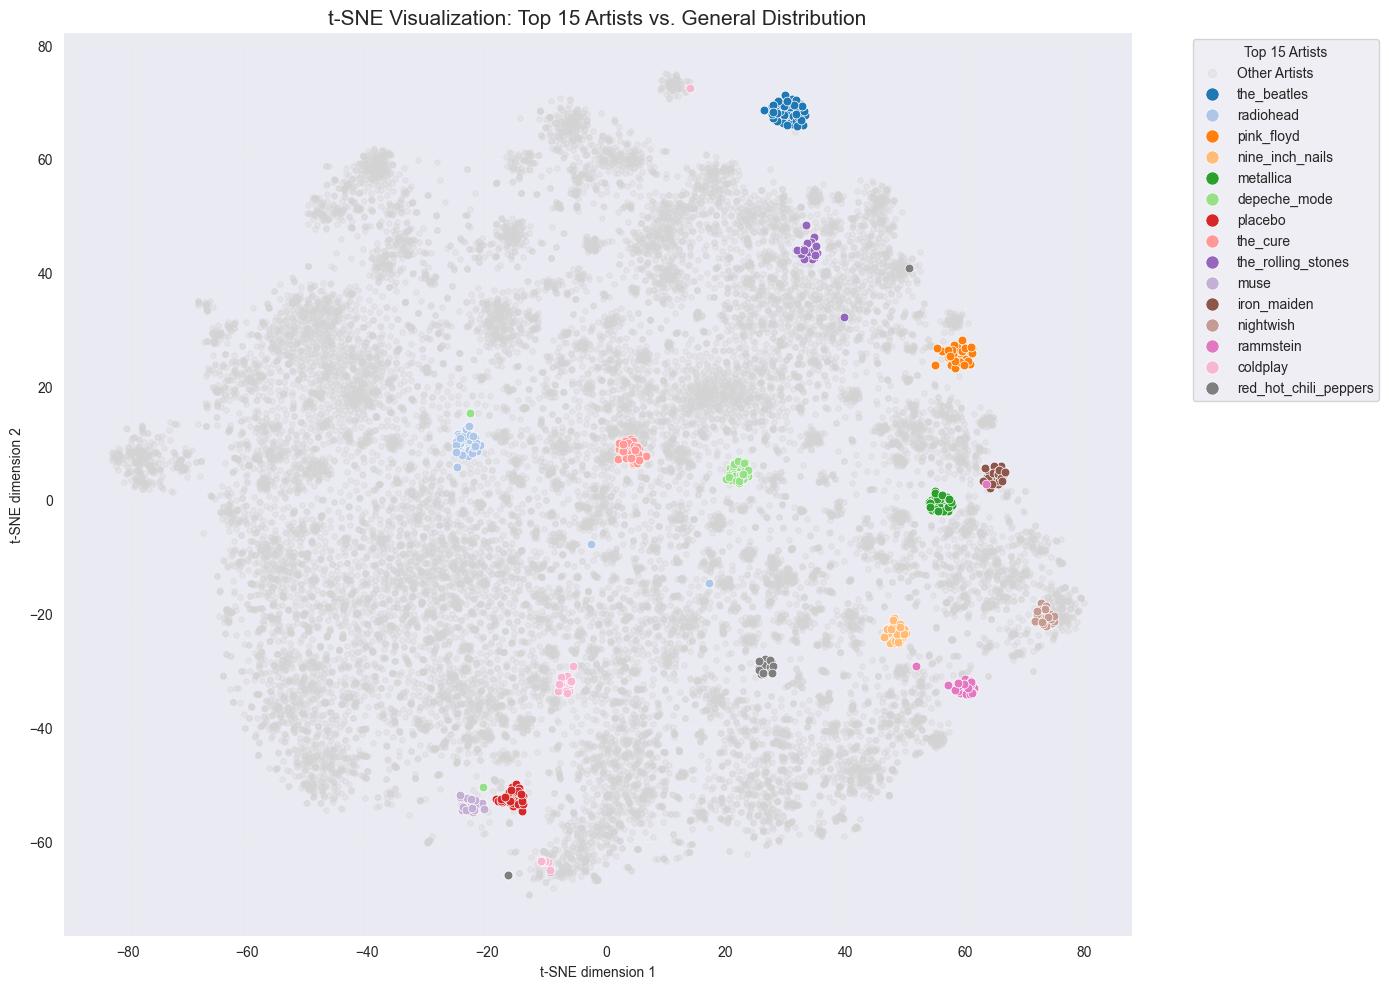

In [257]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import numpy as np
from collections import Counter

# 1. Prepare Data (Let's use the top 2000 songs for a better overview)
n_samples = 21000
top_songs = model_single.wv.index_to_key[:n_samples]
vectors = np.array([model_single.wv[song] for song in top_songs])

# 2. Extract Artist Names
# Assuming format is "artist track" or "artist_track"
artists = [song.split('__')[0] for song in top_songs]
artist_counts = Counter(artists)
top_15_artists = [a for a, _ in artist_counts.most_common(15)]

# 3. Run t-SNE
tsne = TSNE(n_components=2, perplexity=50, random_state=42, init='pca')
vis_dims = tsne.fit_transform(vectors)

# 4. Plotting Logic
plt.figure(figsize=(14, 10))

# First, plot ALL "Other" artists in light gray (the background)
other_indices = [i for i, a in enumerate(artists) if a not in top_15_artists]
plt.scatter(vis_dims[other_indices, 0], vis_dims[other_indices, 1],
            c='lightgray', alpha=0.3, s=15, label='Other Artists')

# Then, plot the Top 15 Artists with distinct colors and legend entries
# We use a colormap with 15+ distinct colors
cmap = plt.get_cmap('tab20')

for i, target_artist in enumerate(top_15_artists):
    indices = [j for j, a in enumerate(artists) if a == target_artist]
    plt.scatter(vis_dims[indices, 0], vis_dims[indices, 1],
                color=cmap(i), label=target_artist, s=40, edgecolors='white', linewidth=0.5)

# 5. Legend and Formatting
plt.title("t-SNE Visualization: Top 15 Artists vs. General Distribution", fontsize=15)
plt.xlabel("t-SNE dimension 1")
plt.ylabel("t-SNE dimension 2")

# Move legend outside the plot area
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Top 15 Artists", markerscale=1.5)
plt.tight_layout()
plt.grid(True, alpha=0.1)
plt.show()

In [258]:
from typing import List

def recommend_songs(seed_songs: List[str], model, top_k: int = 10) -> List[str]:
    """
    Given a list of seed songs, return top_k recommended songs.

    Args:
        seed_songs: List of track identifiers
        model: Trained Word2Vec model
        top_k: Number of recommendations to return

    Returns:
        List of recommended track identifiers
    """
    valid_seeds = [s for s in seed_songs if s in model.wv]

    if not valid_seeds:
        return []

    seed_set = set(valid_seeds)

    try:
        raw_recommendations = model.wv.most_similar(
            positive=valid_seeds,
            topn=top_k + len(seed_set) + 20
        )

        filtered_recommendations = []
        for song, score in raw_recommendations:
            if song not in seed_set:
                filtered_recommendations.append(song)
            if len(filtered_recommendations) == top_k:
                break

        return filtered_recommendations

    except Exception as e:
        print(f"Error generating recommendations: {e}")
        return []

In [259]:
my_seeds = ["queen__bohemian_rhapsody",
    "led_zeppelin__stairway_to_heaven",
    "nirvana__come_as_you_are",
    "coldplay__the_scientist",
    "eminem__lose_yourself"]

# Test with your best model
results = recommend_songs(my_seeds, model_single, top_k=10)

print(f"Recommendations for {my_seeds}:")
for i, rec in enumerate(results, 1):
    print(f"{i}. {rec}")

Recommendations for ['queen__bohemian_rhapsody', 'led_zeppelin__stairway_to_heaven', 'nirvana__come_as_you_are', 'coldplay__the_scientist', 'eminem__lose_yourself']:
1. eagles__hotel_california
2. nirvana__smells_like_teen_spirit
3. red_hot_chili_peppers__californication
4. queen__we_will_rock_you
5. queen__the_show_must_go_on
6. metallica__nothing_else_matters
7. green_day__boulevard_of_broken_dreams
8. aerosmith__i_dont_want_to_miss_a_thing
9. the_doors__light_my_fire
10. rem__losing_my_religion


In [260]:
my_seeds = ["queen__bohemian_rhapsody"]

# Test with your best model
results = recommend_songs(my_seeds, model_avg, top_k=10)

print(f"Recommendations for {my_seeds}:")
for i, rec in enumerate(results, 1):
    print(f"{i}. {rec}")

Recommendations for ['queen__bohemian_rhapsody']:
1. queen__we_will_rock_you
2. queen__the_show_must_go_on
3. queen__another_one_bites_the_dust
4. queen__killer_queen
5. queen__we_are_the_champions
6. queen__somebody_to_love
7. queen__dont_stop_me_now
8. queen__i_want_to_break_free
9. queen__bicycle_race
10. queen__under_pressure


In [261]:
my_seeds = ["led_zeppelin__stairway_to_heaven"]

results = recommend_songs(my_seeds, model_avg, top_k=10)

print(f"Recommendations for {my_seeds}:")
for i, rec in enumerate(results, 1):
    print(f"{i}. {rec}")

Recommendations for ['led_zeppelin__stairway_to_heaven']:
1. led_zeppelin__whole_lotta_love
2. led_zeppelin__kashmir
3. led_zeppelin__immigrant_song
4. led_zeppelin__black_dog
5. led_zeppelin__tangerine
6. deep_purple__smoke_on_the_water
7. led_zeppelin__since_ive_been_loving_you
8. led_zeppelin__dazed_and_confused
9. led_zeppelin__rock_and_roll
10. led_zeppelin__going_to_california


In [262]:
my_seeds = ["nirvana__come_as_you_are"]

results = recommend_songs(my_seeds, model_avg, top_k=10)

print(f"Recommendations for {my_seeds}:")
for i, rec in enumerate(results, 1):
    print(f"{i}. {rec}")

Recommendations for ['nirvana__come_as_you_are']:
1. nirvana__lithium
2. nirvana__smells_like_teen_spirit
3. nirvana__in_bloom
4. nirvana__rape_me
5. nirvana__about_a_girl
6. nirvana__polly
7. nirvana__all_apologies
8. nirvana__territorial_pissings
9. nirvana__the_man_who_sold_the_world
10. nirvana__stay_away


In [263]:
my_seeds = ["coldplay__the_scientist"]

results = recommend_songs(my_seeds, model_avg, top_k=10)

print(f"Recommendations for {my_seeds}:")
for i, rec in enumerate(results, 1):
    print(f"{i}. {rec}")

Recommendations for ['coldplay__the_scientist']:
1. coldplay__fix_you
2. coldplay__yellow
3. coldplay__clocks
4. coldplay__trouble
5. coldplay__in_my_place
6. coldplay__speed_of_sound
7. coldplay__dont_panic
8. coldplay__green_eyes
9. coldplay__warning_sign
10. coldplay__what_if


In [264]:
my_seeds = ["eminem__lose_yourself"]

results = recommend_songs(my_seeds, model_avg, top_k=10)

print(f"Recommendations for {my_seeds}:")
for i, rec in enumerate(results, 1):
    print(f"{i}. {rec}")

Recommendations for ['eminem__lose_yourself']:
1. eminem__mockingbird
2. eminem__without_me
3. eminem__the_real_slim_shady
4. d12__how_come
5. eminem__like_toy_soldiers
6. eminem__ass_like_that
7. d12__my_band
8. eminem__white_america
9. eminem__cleanin_out_my_closet
10. flo_rida__low


In [265]:
my_seeds = ["radiohead__creep"]

results = recommend_songs(my_seeds, model_avg, top_k=10)

print(f"Recommendations for {my_seeds}:")
for i, rec in enumerate(results, 1):
    print(f"{i}. {rec}")

Recommendations for ['radiohead__creep']:
1. radiohead__karma_police
2. radiohead__paranoid_android
3. radiohead__no_surprises
4. radiohead__street_spirit_fade_out
5. radiohead__just
6. radiohead__lucky
7. radiohead__high_and_dry
8. radiohead__fake_plastic_trees
9. radiohead__idioteque
10. radiohead__the_bends


In [266]:
my_seeds = ["metallica__nothing_else_matters"]

results = recommend_songs(my_seeds, model_avg, top_k=10)

print(f"Recommendations for {my_seeds}:")
for i, rec in enumerate(results, 1):
    print(f"{i}. {rec}")

Recommendations for ['metallica__nothing_else_matters']:
1. metallica__the_unforgiven
2. metallica__enter_sandman
3. metallica__fade_to_black
4. metallica__master_of_puppets
5. metallica__one
6. metallica__sad_but_true
7. metallica__fuel
8. metallica__the_unforgiven_ii
9. metallica__welcome_home_sanitarium
10. metallica__turn_the_page


In [267]:
my_seeds = ["eminem__drug_ballad"]

results = recommend_songs(my_seeds, model_avg, top_k=10)

print(f"Recommendations for {my_seeds}:")
for i, rec in enumerate(results, 1):
    print(f"{i}. {rec}")

Recommendations for ['eminem__drug_ballad']:
1. 2pac__dear_mama
2. eminem__kim
3. eminem__like_toy_soldiers
4. eminem__without_me
5. eminem__till_i_collapse
6. 2pac__life_goes_on
7. eminem__stan
8. eminem__just_lose_it
9. eminem__ass_like_that
10. eminem__the_real_slim_shady


In [268]:
from collections import Counter

all_train_songs = [song for playlist in train_sentences for song in playlist]
song_counts = Counter(all_train_songs)
total_unique_tracks = len(song_counts)

print("--- Excluded Unique Tracks by min_count ---")
for mc in [3, 5, 10]:
    excluded_tracks = [s for s, c in song_counts.items() if c < mc]
    perc_excluded = 100 * len(excluded_tracks) / total_unique_tracks
    print(f"min_count={mc}: {perc_excluded:.2f}% excluded")

# 3. Test Set OOV Rate
# Assuming test_set is a list of (seed, ground_truth) tuples
all_test_songs = [song for playlist in test_sentences for song in playlist]
oov_test_songs = [s for s in all_test_songs if s not in model_single.wv]
perc_oov_test = (len(oov_test_songs) / len(all_test_songs)) * 100

print(f"--- Cold-Start Metrics ---")
print(f"Tracks Excluded by min_count: {perc_excluded:.2f}%")
print(f"Test Set OOV Rate: {perc_oov_test:.2f}%")

--- Excluded Unique Tracks by min_count ---
min_count=3: 72.88% excluded
min_count=5: 86.05% excluded
min_count=10: 94.53% excluded
--- Cold-Start Metrics ---
Tracks Excluded by min_count: 94.53%
Test Set OOV Rate: 59.57%


In [269]:
def calculate_subset_hr(test_playlists, model, bucket_type, train_song_counts):
    hits = 0
    count = 0
    vocab = model.wv.key_to_index

    for playlist in test_playlists:
        if len(playlist) < 2:
            continue

        target = playlist[-1]
        query_song = playlist[-2]
        freq = train_song_counts.get(target, 0)

        if bucket_type == "frequent":
            if freq <= 100:
                continue
        elif bucket_type == "rare":
            if freq >= 10:
                continue
        else:
            raise ValueError("bucket_type must be 'frequent' or 'rare'")

        if target not in vocab or query_song not in vocab:
            continue

        raw_recs = model.wv.most_similar(query_song, topn=11)
        recs = [song for song, score in raw_recs if song != query_song][:10]

        if target in recs:
            hits += 1
        count += 1

    return hits / count if count > 0 else 0

hr_frequent = calculate_subset_hr(test_sentences, model_single, "frequent", song_counts)
hr_rare = calculate_subset_hr(test_sentences, model_single, "rare", song_counts)

print("\n--- HR@10 Performance Comparison ---")
print(f"Frequent songs (>100): {hr_frequent:.4f}")
print(f"Rare songs (<10):      {hr_rare:.4f}")


--- HR@10 Performance Comparison ---
Frequent songs (>100): 0.1566
Rare songs (<10):      0.0000


In [270]:
bad_cases = []
failure_count = 0

for playlist in test_sentences:
    if len(playlist) < 2:
        continue

    target = playlist[-1]
    query = playlist[-2]

    if query in model_single.wv:
        recs = [r[0] for r in model_single.wv.most_similar(query, topn=10)]

        if target not in recs:
            top_rec = recs[0]



            bad_cases.append({
                "Input/Query": query,
                "Model Output": top_rec,
                "Expected": target
            })
            failure_count += 1

    else:
        bad_cases.append({
            "Input/Query": query,
            "Model Output": "[COLD START - OOV]",
            "Expected": target,
        })
        failure_count += 1

    if failure_count >= 10:
        break

bad_cases_df = pd.DataFrame(bad_cases)
print(bad_cases_df)

                          Input/Query                           Model Output  \
0         joe_louis_walker__nighttime                     [COLD START - OOV]   
1               fear_factory__replica          sepultura__roots_bloody_roots   
2              milton_cardona__elegua                     [COLD START - OOV]   
3                seapony__prove_to_me                     [COLD START - OOV]   
4         u-roy__wear_you_to_the_ball                     [COLD START - OOV]   
5                 champion__no_heaven                     [COLD START - OOV]   
6    temple_of_the_dog__hunger_strike  temple_of_the_dog__say_hello_2_heaven   
7          ane_brun__to_let_myself_go             ane_brun__my_lover_will_go   
8  amy_winehouse__you_know_im_no_good           amy_winehouse__back_to_black   
9             fat_truckers__superbike                     [COLD START - OOV]   

                                            Expected  
0                     stevie_ray_vaughan__empty_arms  
1  revere

In [271]:
import numpy as np

def get_artist_name(song_id):
    return song_id.split('__')[0] if '__' in song_id else song_id

def raw_single_query_recs(query_song, model, top_k=10):
    """
    Standard single-query recommendations.
    Returns [] if query is OOV.
    """
    if query_song not in model.wv:
        return []

    raw = model.wv.most_similar(query_song, topn=top_k + 1)
    recs = [song for song, score in raw if song != query_song][:top_k]
    return recs

def get_artist_proxy_vector(oov_song, model):
    """
    If a song is OOV, use the average embedding of other in-vocab songs
    by the same artist as a proxy.
    """
    artist = get_artist_name(oov_song)
    artist_songs = [s for s in model.wv.index_to_key if get_artist_name(s) == artist]

    if not artist_songs:
        return None

    return np.mean([model.wv[s] for s in artist_songs], axis=0)

def recommend_with_artist_fallback(seed_song, model, top_k=10):
    """
    Before/after fix for cold-start:
    If seed song is OOV, use artist-level proxy vector.
    """
    if seed_song in model.wv:
        return raw_single_query_recs(seed_song, model, top_k=top_k)

    proxy_vec = get_artist_proxy_vector(seed_song, model)
    if proxy_vec is None:
        return []

    raw = model.wv.similar_by_vector(proxy_vec, topn=top_k + 20)
    recs = [song for song, score in raw if song != seed_song][:top_k]
    return recs

def recommend_no_same_artist(query_song, model, top_k=10):
    """
    Before/after fix for artist over-representation:
    Remove same-artist songs from recommendation list.
    """
    if query_song not in model.wv:
        return []

    query_artist = get_artist_name(query_song)
    raw = model.wv.most_similar(query_song, topn=top_k + 30)

    filtered = []
    for song, score in raw:
        if song == query_song:
            continue
        if get_artist_name(song) == query_artist:
            continue
        filtered.append(song)
        if len(filtered) == top_k:
            break

    return filtered

In [272]:
cold_start_case = None

for playlist in test_sentences:
    if len(playlist) < 2:
        continue

    query = playlist[-2]
    target = playlist[-1]

    if query not in model_single.wv:
        proxy = get_artist_proxy_vector(query, model_single)
        if proxy is not None:
            cold_start_case = (query, target)
            break

if cold_start_case is None:
    print("No suitable cold-start case with artist fallback found.")
else:
    query, target = cold_start_case

    print("=== FAILURE CASE 1: COLD-START FAILURE ===")
    print(f"Query:    {query}")
    print(f"Expected: {target}")

    print("\nBefore fix:")
    before_recs = raw_single_query_recs(query, model_single, top_k=5)
    if not before_recs:
        print("[COLD START - OOV] No recommendations available.")
    else:
        for i, rec in enumerate(before_recs, 1):
            print(f"{i}. {rec}")

    print("\nAfter fix (artist-level fallback):")
    after_recs = recommend_with_artist_fallback(query, model_single, top_k=5)
    if not after_recs:
        print("No fallback recommendations available.")
    else:
        for i, rec in enumerate(after_recs, 1):
            print(f"{i}. {rec}")

=== FAILURE CASE 1: COLD-START FAILURE ===
Query:    au_revoir_simone__only_you_can_make_you_happy
Expected: sublime__doin_time

Before fix:
[COLD START - OOV] No recommendations available.

After fix (artist-level fallback):
1. au_revoir_simone__sad_song
2. au_revoir_simone__shadows
3. au_revoir_simone__a_violent_yet_flammable_world
4. florence__the_machine__my_boy_builds_coffins
5. au_revoir_simone__the_lucky_one


In [273]:
artist_overrep_case = None

for playlist in test_sentences:
    if len(playlist) < 2:
        continue

    query = playlist[-2]
    target = playlist[-1]

    if query not in model_single.wv:
        continue

    raw_recs = raw_single_query_recs(query, model_single, top_k=10)
    if not raw_recs:
        continue

    top_rec = raw_recs[0]

    if get_artist_name(top_rec) == get_artist_name(query) and get_artist_name(target) != get_artist_name(query):
        artist_overrep_case = (query, target, top_rec)
        break

if artist_overrep_case is None:
    print("No suitable artist over-representation case found.")
else:
    query, target, top_rec = artist_overrep_case

    print("=== FAILURE CASE 2: ARTIST OVER-REPRESENTATION ===")
    print(f"Query:    {query}")
    print(f"Expected: {target}")

    print("\nBefore fix:")
    before_recs = raw_single_query_recs(query, model_single, top_k=5)
    for i, rec in enumerate(before_recs, 1):
        print(f"{i}. {rec}")

    print("\nAfter fix (same-artist filtering):")
    after_recs = recommend_no_same_artist(query, model_single, top_k=5)
    for i, rec in enumerate(after_recs, 1):
        print(f"{i}. {rec}")

=== FAILURE CASE 2: ARTIST OVER-REPRESENTATION ===
Query:    temple_of_the_dog__hunger_strike
Expected: soundgarden__fresh_tendrils

Before fix:
1. temple_of_the_dog__say_hello_2_heaven
2. soundgarden__burden_in_my_hand
3. alice_in_chains__would
4. temple_of_the_dog__pushin_forward_back
5. temple_of_the_dog__call_me_a_dog

After fix (same-artist filtering):
1. soundgarden__burden_in_my_hand
2. alice_in_chains__would
3. soundgarden__outshined
4. soundgarden__spoonman
5. alice_in_chains__rooster


In [274]:
# --- Q2: Playlist Length Effect ---
def eval_by_length(model, test_sentences):
    buckets = {'short': [], 'medium': [], 'long': []}
    for p in test_sentences:
        if len(p) < 2: continue
        if len(p) < 10: buckets['short'].append(p)
        elif 10 <= len(p) <= 30: buckets['medium'].append(p)
        else: buckets['long'].append(p)

    for label, data in buckets.items():
        res = calculate_metrics(model, data, approach="single", k_values=[10])
        print(f"Playlist Length {label} (N={len(data)}): HR@10 = {res['HR@10']:.4f}")

# --- Q3: Vocabulary Counts ---
total_unique = len(song_counts)
for mc in [3, 5, 10]:
    in_vocab = sum(1 for c in song_counts.values() if c >= mc)
    print(f"min_count={mc}: {in_vocab} unique tracks in vocabulary")

print("\n--- Running Diagnostics ---")
eval_by_length(model_single, test_sentences)

min_count=3: 106097 unique tracks in vocabulary
min_count=5: 54582 unique tracks in vocabulary
min_count=10: 21396 unique tracks in vocabulary

--- Running Diagnostics ---
Playlist Length short (N=3225): HR@10 = 0.1176
Playlist Length medium (N=3334): HR@10 = 0.1367
Playlist Length long (N=2878): HR@10 = 0.1305


In [277]:
  # Extract the parameters for the best single-query candidate
best_params = candidate_configs[best_single_row['Source_df']]['params']

print(f"{'Hyperparameter':<15} | {'Value':<10}")
print("-" * 30)
for param, value in best_params.items():
    print(f"{param:<15} | {value:<10}")

Hyperparameter  | Value     
------------------------------
vector_size     | 50        
window          | 40        
min_count       | 10        
sg              | 1         
negative        | 15        
ns_exponent     | 1.0       
workers         | 4         
epochs          | 20        
seed            | 42        


In [279]:
# Save the full model (includes weights, vocabulary, and training state)
model_single.save("song2vec_optimized_single.model")